In [13]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [14]:
X = np.array([0,1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([0,0,0,0,0,0,1,1,1,1,1])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (11, 1)
y shape: (11,)


In [15]:
model = keras.Sequential([
    layers.Dense(8, activation="relu", input_shape=(1,)),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57 (228.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [17]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [18]:
history = model.fit(X, y, epochs=200, verbose=0)


In [19]:
loss, acc = model.evaluate(X, y, verbose=0)
print("Training Accuracy:", acc)


Training Accuracy: 0.7272727489471436


In [20]:
new_value = np.array([[5.5]])
prediction = model.predict(new_value)

print("Raw prediction:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Class → 1")
else:
    print("Class → 0")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Raw prediction: 0.68494874
Class → 1


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


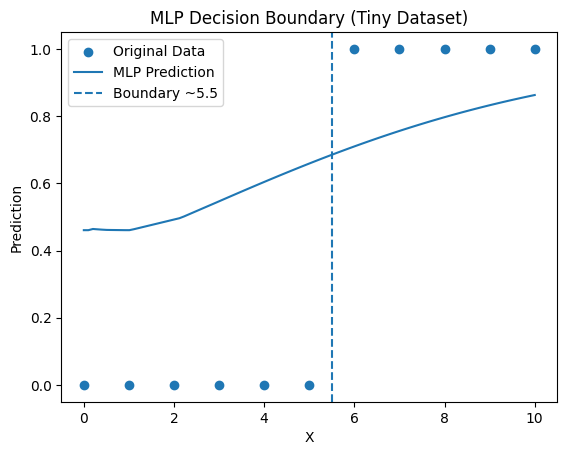

In [21]:
x_plot = np.linspace(0, 10, 100).reshape(-1,1)
y_plot = model.predict(x_plot)

plt.scatter(X, y, label="Original Data")
plt.plot(x_plot, y_plot, label="MLP Prediction")
plt.axvline(5.5, linestyle="--", label="Boundary ~5.5")

plt.xlabel("X")
plt.ylabel("Prediction")
plt.title("MLP Decision Boundary (Tiny Dataset)")
plt.legend()
plt.show()


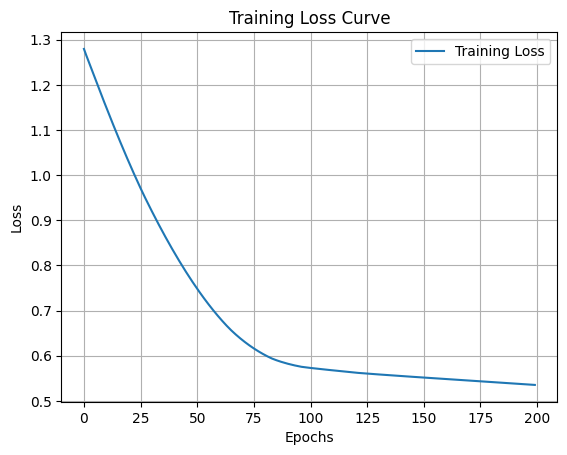

In [22]:
plt.plot(history.history['loss'], label="Training Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()
